## Handwritten Digit Recognition

### 1.Import Libraries

In [14]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.utils import to_categorical

### 2. LOAD DATASET

In [4]:

train_data = pd.read_csv("/content/sample_data/mnist_train_small.csv")
test_data = pd.read_csv("/content/sample_data/mnist_test.csv")

# Display dataset shapes
print("Training Dataset Shape :", train_data.shape)
print("Testing Dataset Shape :", test_data.shape)

# Display first 5 rows
print(train_data.head())
print(test_data.head())

Training Dataset Shape : (19999, 785)
Testing Dataset Shape : (9999, 785)
   6  0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  ...  0.581  0.582  0.583  \
0  5  0    0    0    0    0    0    0    0    0  ...      0      0      0   
1  7  0    0    0    0    0    0    0    0    0  ...      0      0      0   
2  9  0    0    0    0    0    0    0    0    0  ...      0      0      0   
3  5  0    0    0    0    0    0    0    0    0  ...      0      0      0   
4  2  0    0    0    0    0    0    0    0    0  ...      0      0      0   

   0.584  0.585  0.586  0.587  0.588  0.589  0.590  
0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0  

[5 rows x 785 columns]
   7  0  0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  ...  0.658  0.659  0.660  \
0  2  0    0    0    0    0    0    0    0  

### 5.Separate Features and Labels

In [5]:
# First column contains labels

y_train = train_data.iloc[:,0]

# Remaining columns contain pixel values

X_train = train_data.iloc[:,1:]

# Test dataset

y_test = test_data.iloc[:,0]

X_test = test_data.iloc[:,1:]

### 6.Convert Data into NumPy Arrays

In [6]:
X_train = np.array(X_train)

X_test = np.array(X_test)

y_train = np.array(y_train)

y_test = np.array(y_test)

### 7.Display Sample Image

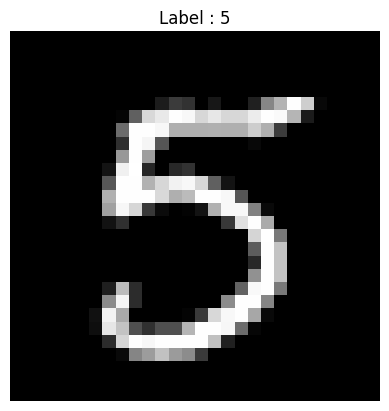

In [7]:
# Display first image

plt.imshow(X_train[0].reshape(28,28), cmap='gray')

plt.title("Label : " + str(y_train[0]))

plt.axis('off')

plt.show()

### 8.Data Cleaning and Preprocessing

### 8.1 Normalize Pixel Values

In [8]:
# Convert values between 0 and 1

X_train = X_train / 255.0

X_test = X_test / 255.0

### 8.2 Reshape Dataset for CNN

In [9]:
# Reshape into 4D format

X_train = X_train.reshape(-1,28,28,1)

X_test = X_test.reshape(-1,28,28,1)

print("Training Shape :", X_train.shape)

print("Testing Shape :", X_test.shape)

Training Shape : (19999, 28, 28, 1)
Testing Shape : (9999, 28, 28, 1)


### 8.3 Convert Labels into Categorical Format

In [10]:
# One-hot encoding

y_train = to_categorical(y_train,10)

y_test = to_categorical(y_test,10)

### 9.Build CNN Model

In [11]:
# Create model

model = Sequential()

### 9.1 Add First Convolution Layer

In [12]:
model.add(

    Conv2D(

        filters = 32,

        kernel_size = (3,3),

        activation = 'relu',

        input_shape = (28,28,1)
    )
)

model.add(

    MaxPooling2D(pool_size=(2,2))
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 9.2 Add Second Convolution Layer

In [13]:
model.add(

    Conv2D(

        filters = 64,

        kernel_size = (3,3),

        activation = 'relu'
    )
)

model.add(

    MaxPooling2D(pool_size=(2,2))
)

### 9.3 Flatten Layer

In [15]:
model.add(Flatten())

### 9.4 Fully Connected Layer

In [16]:
model.add(

    Dense(

        units = 128,

        activation = 'relu'
    )
)

model.add(

    Dropout(0.3)
)

### 9.5 Output Layer

In [17]:
model.add(

    Dense(

        units = 10,

        activation = 'softmax'
    )
)

### 10.Compile the Model

In [18]:
model.compile(

    optimizer = 'adam',

    loss = 'categorical_crossentropy',

    metrics = ['accuracy']
)

### 11.View Model Summary

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### 12.Train the Model

In [20]:
history = model.fit(

    X_train,

    y_train,

    epochs = 5,

    batch_size = 64,

    validation_split = 0.2
)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step - accuracy: 0.8690 - loss: 0.4322 - val_accuracy: 0.9600 - val_loss: 0.1262
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.9629 - loss: 0.1231 - val_accuracy: 0.9758 - val_loss: 0.0793
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.9741 - loss: 0.0801 - val_accuracy: 0.9803 - val_loss: 0.0588
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.9801 - loss: 0.0639 - val_accuracy: 0.9847 - val_loss: 0.0500
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step - accuracy: 0.9850 - loss: 0.0471 - val_accuracy: 0.9837 - val_loss: 0.0533


### 13.Evaluate the Model

In [21]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy :", accuracy * 100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9828 - loss: 0.0523
Test Accuracy : 98.27982783317566


### 14.Plot Accuracy Graph

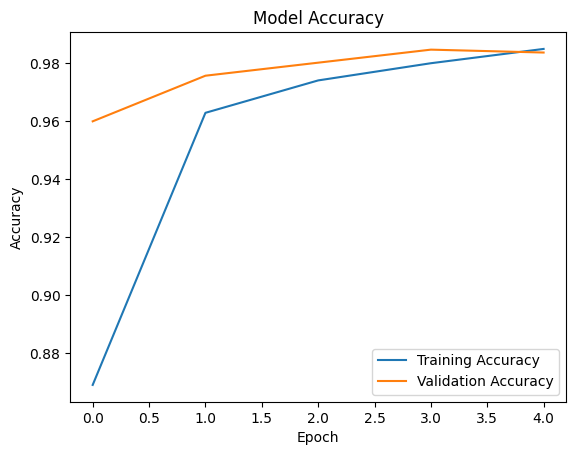

In [22]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Training Accuracy","Validation Accuracy"])

plt.show()

### 15.Make Predictions

In [23]:
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


### 16.Display Predicted Images

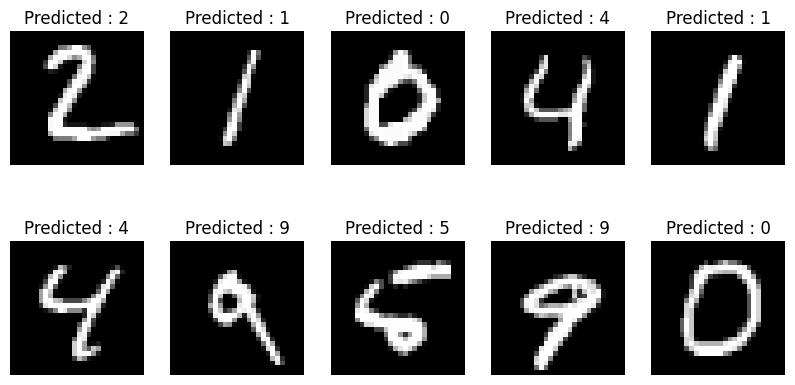

In [24]:
plt.figure(figsize=(10,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_test[i].reshape(28,28), cmap='gray')

    predicted_label = np.argmax(predictions[i])

    plt.title("Predicted : " + str(predicted_label))

    plt.axis('off')

plt.show()

### 17.Save the Model

In [25]:
model.save("handwritten_digit_model.h5")

print("Model Saved Successfully")

Model Saved Successfully
